In [2]:
import numpy as np
import pandas as pd
import torch
import evaluate

from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

In [4]:
df = pd.read_csv("../data/processed/clean_reviews.csv")
df = df[["text", "label"]].copy()

print(df.shape)
df.head()

(1596, 2)


,text,label
0,We stayed for a one night getaway with family ...,0
1,Triple A rate with upgrade to view room was le...,0
2,This comes a little late as I'm finally catchi...,0
3,The Omni Chicago really delivers on all fronts...,0
4,I asked for a high floor away from the elevato...,0


In [5]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df["label"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain label dağılımı:")
print(train_df["label"].value_counts())

print("\nValidation label dağılımı:")
print(val_df["label"].value_counts())

print("\nTest label dağılımı:")
print(test_df["label"].value_counts())

Train: (1148, 2)
Validation: (128, 2)
Test: (320, 2)

Train label dağılımı:
label
1    576
0    572
Name: count, dtype: int64

Validation label dağılımı:
label
0    64
1    64
Name: count, dtype: int64

Test label dağılımı:
label
1    160
0    160
Name: count, dtype: int64


In [6]:
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 1148
})

In [7]:
model_checkpoint = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=2
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [8]:
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True)

tokenized_train = train_ds.map(tokenize_function, batched=True)
tokenized_val = val_ds.map(tokenize_function, batched=True)
tokenized_test = test_ds.map(tokenize_function, batched=True)

Map:   0%|          | 0/1148 [00:00<?, ? examples/s]

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

In [9]:
tokenized_train = tokenized_train.remove_columns(
    [col for col in tokenized_train.column_names if col not in ["input_ids", "attention_mask", "label"]]
)
tokenized_val = tokenized_val.remove_columns(
    [col for col in tokenized_val.column_names if col not in ["input_ids", "attention_mask", "label"]]
)
tokenized_test = tokenized_test.remove_columns(
    [col for col in tokenized_test.column_names if col not in ["input_ids", "attention_mask", "label"]]
)

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

In [10]:
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    precision = precision_metric.compute(predictions=predictions, references=labels)
    recall = recall_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels)

    return {
        "accuracy": accuracy["accuracy"],
        "precision": precision["precision"],
        "recall": recall["recall"],
        "f1": f1["f1"],
    }

In [11]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [14]:
training_args = TrainingArguments(
    output_dir="../results/distilbert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

In [18]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("trainer oluşturuldu")

trainer oluşturuldu


In [19]:
trainer.train()

/Users/bilalaksel/Desktop/Projects/TruthReview/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.494095,0.334461,0.882812,0.865672,0.906250,0.885496
2,0.239180,0.365860,0.898438,0.859155,0.953125,0.903704
3,0.141510,0.424511,0.906250,0.861111,0.968750,0.911765


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/bilalaksel/Desktop/Projects/TruthReview/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/bilalaksel/Desktop/Projects/TruthReview/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=432, training_loss=0.2915948850137216, metrics={'train_runtime': 128.8577, 'train_samples_per_second': 26.727, 'train_steps_per_second': 3.353, 'total_flos': 305278364513616.0, 'train_loss': 0.2915948850137216, 'epoch': 3.0})

In [23]:
pred_output_val = trainer.predict(tokenized_val)

y_val_bert = pred_output_val.label_ids
y_pred_val_bert = np.argmax(pred_output_val.predictions, axis=-1)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Validation Accuracy:", accuracy_score(y_val_bert, y_pred_val_bert))
print("\nValidation Classification Report:\n")
print(classification_report(y_val_bert, y_pred_val_bert))
print("\nValidation Confusion Matrix:\n")
print(confusion_matrix(y_val_bert, y_pred_val_bert))

/Users/bilalaksel/Desktop/Projects/TruthReview/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Validation Accuracy: 0.90625

Validation Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.84      0.90        64
           1       0.86      0.97      0.91        64

    accuracy                           0.91       128
   macro avg       0.91      0.91      0.91       128
weighted avg       0.91      0.91      0.91       128


Validation Confusion Matrix:

[[54 10]
 [ 2 62]]


In [24]:
pred_output_test = trainer.predict(tokenized_test)

y_test_bert = pred_output_test.label_ids
y_pred_bert = np.argmax(pred_output_test.predictions, axis=-1)

print("Test Accuracy:", accuracy_score(y_test_bert, y_pred_bert))
print("\nTest Classification Report:\n")
print(classification_report(y_test_bert, y_pred_bert))
print("\nTest Confusion Matrix:\n")
print(confusion_matrix(y_test_bert, y_pred_bert))

/Users/bilalaksel/Desktop/Projects/TruthReview/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Test Accuracy: 0.8875

Test Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.83      0.88       160
           1       0.85      0.94      0.89       160

    accuracy                           0.89       320
   macro avg       0.89      0.89      0.89       320
weighted avg       0.89      0.89      0.89       320


Test Confusion Matrix:

[[133  27]
 [  9 151]]


In [25]:
import os
os.makedirs("../results/figures", exist_ok=True)

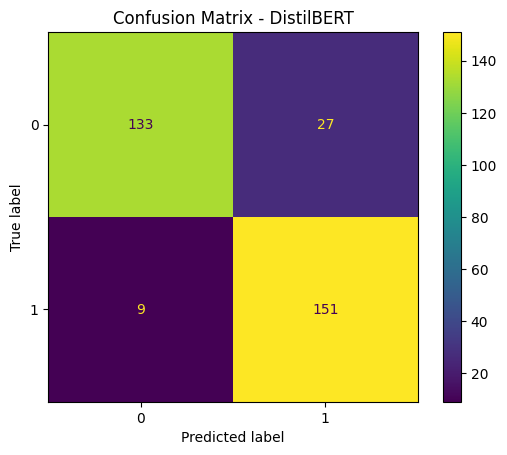

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_bert = confusion_matrix(y_test_bert, y_pred_bert)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_bert)
disp.plot()
plt.title("Confusion Matrix - DistilBERT")
plt.savefig("../results/figures/confusion_matrix_distilbert.png", bbox_inches="tight")
plt.show()

In [27]:
comparison_df = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Multinomial Naive Bayes",
        "DistilBERT"
    ],
    "Accuracy": [
        0.890625,
        0.859375,
        0.8875
    ]
})

comparison_df

,Model,Accuracy
0,TF-IDF + Logistic Regression,0.890625
1,TF-IDF + Multinomial Naive Bayes,0.859375
2,DistilBERT,0.887500
